# <center> Sweeping variables demonstration

### <center> In this demo you will sweep the amplitude of a pulse in loopback to demonstrate control over the QICK. 

We will sweep in two ways:
* Within the QICK assembly language (advantage: faster, disadvantage: cannot be used to sweep the readout frequency)
* With a Python outer loop (advantage: can sweep any parameter, disadvantage: slower)

In [109]:
# Import the QICK drivers and auxiliary libraries
from qick import *
from tqdm.notebook import tqdm
%pylab inline

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


/usr/local/share/pynq-venv/lib/python3.10/site-packages/IPython/core/magics/pylab.py:162: UserWarning: pylab import has clobbered these variables: ['trace']
`%matplotlib` prevents importing * from pylab and numpy
  warn("pylab import has clobbered these variables: %s"  % clobbered +


In [110]:
# Load bitstream with custom overlay
soc = QickSoc()
# Since we're running locally on the QICK, we don't need a separate QickConfig object.
# If running remotely, you could generate a QickConfig from the QickSoc:
#     soccfg = QickConfig(soc.get_cfg())
# or save the config to file, and load it later:
#     with open("qick_config.json", "w") as f:
#         f.write(soc.dump_cfg())
#     soccfg = QickConfig("qick_config.json")
soccfg = soc
# print(soccfg)


### Hardware Configuration

tProc channel 7   : DAC 229 CH3  <-> Readout channel 0 : ADC 224 CH0

In [111]:
class LoopbackProgram(AveragerProgram):
    def initialize(self):
        cfg=self.cfg   

        # set the nyquist zone
        self.declare_gen(ch=cfg["res_ch"], nqz=1)

        #configure the readout lengths and downconversion frequencies
        self.declare_readout(ch=cfg["ro_ch"], length=self.cfg["readout_length"],
                             freq=self.cfg["pulse_freq"], gen_ch=cfg["res_ch"])

        freq=self.freq2reg(cfg["pulse_freq"], gen_ch=cfg["res_ch"], ro_ch=cfg["ro_ch"])  # convert frequency to dac frequency (ensuring it is an available adc frequency)
        self.set_pulse_registers(ch=cfg["res_ch"], style="const", freq=freq, phase=0, gain=cfg["pulse_gain"], 
                                 length=cfg["length"])
        self.synci(200)  # give processor some time to configure pulses
    
    def body(self):
        self.measure(pulse_ch=self.cfg["res_ch"], 
             adcs=[self.cfg["ro_ch"]],
             adc_trig_offset=self.cfg["adc_trig_offset"],
             wait=True,
             syncdelay=self.us2cycles(self.cfg["relax_delay"]))

In [112]:
from qick.averager_program import AveragerProgram

class ChirpOnlyProgram(AveragerProgram):
    def initialize(self):
        cfg = self.cfg
        self.declare_gen(ch=cfg["res_ch"], nqz=1)
        # no declare_readout needed at all if you truly don't care about the ADC

        self.r_rp = self.ch_page(cfg["res_ch"])
        self.r_freq  = self.sreg(cfg["res_ch"], "freq")
        self.r_phase = self.sreg(cfg["res_ch"], "phase")

        self.r_vel      = 9
        self.r_accel    = 10
        self.r_freq_max = 11

        freq0    = self.freq2reg(cfg["freq_start"], gen_ch=cfg["res_ch"])
        freq_max = self.freq2reg(cfg["freq_max"],   gen_ch=cfg["res_ch"])
        vel0     = self.freq2reg(cfg["vel_start"],  gen_ch=cfg["res_ch"])
        accel    = self.freq2reg(cfg["accel"],      gen_ch=cfg["res_ch"])

        self.span = freq_max - freq0
        if self.span <= 0:
            raise RuntimeError("freq_max must be greater than freq_start")

        self.regwi(self.r_rp, self.r_vel,      vel0,     "vel = vel_start")
        self.regwi(self.r_rp, self.r_accel,    accel,    "accel")
        self.regwi(self.r_rp, self.r_freq_max, freq_max, "freq_max (wrap threshold)")

        self.set_pulse_registers(ch=cfg["res_ch"], style="const", freq=freq0,
                                  phase=0, gain=cfg["pulse_gain"], length=cfg["seg_len"])
        self.synci(200)

    def body(self):
        cfg = self.cfg
        n_segments = cfg["n_segments"]

        # NO trigger(), NO ADC involvement at all -- pure DAC output loop
        for i in range(n_segments):
            self.regwi(self.r_rp, self.r_phase, 0, "reset phase")
            self.pulse(ch=cfg["res_ch"])

            self.math(self.r_rp, self.r_vel, self.r_vel, '+', self.r_accel)
            self.math(self.r_rp, self.r_freq, self.r_freq, '+', self.r_vel)
            skip_label = f"SKIP_WRAP_{i}"
            self.condj(self.r_rp, self.r_freq, "<", self.r_freq_max, skip_label)
            self.mathi(self.r_rp, self.r_freq, self.r_freq, "-", self.span)
            self.label(skip_label)

        self.sync_all(self.us2cycles(cfg["relax_delay"]))

    def update(self):
        self.math(self.r_rp, self.r_vel, self.r_vel, '+', self.r_accel)
        self.math(self.r_rp, self.r_freq, self.r_freq, '+', self.r_vel)

        self.condj(self.r_rp, self.r_freq, "<", self.r_freq_max, "SKIP_WRAP_UPDATE")
        self.mathi(self.r_rp, self.r_freq, self.r_freq, "-", self.span)
        self.math(self.r_rp, self.r_vel, self.r_vel0, '+', 0)
        self.label("SKIP_WRAP_UPDATE")

    def get_expt_pts(self):
        """Simulate the same recursion in Python (float MHz) to get the x-axis,
        including wraps."""
        n = self.cfg["expts"]
        f = self.cfg["freq_start"]
        v = self.cfg["vel_start"]
        a = self.cfg["accel"]
        span = self.cfg["freq_max"] - self.cfg["freq_start"]
        pts = [f]
        for _ in range(n - 1):
            v += a
            f += v
            if f >= self.cfg["freq_max"]:
                f -= span
                v = self.cfg["vel_start"]  # keep in sync with the reset above
            pts.append(f)
        return np.array(pts)

### Sweeping via the QICK assembly language


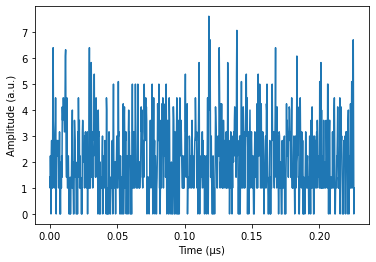

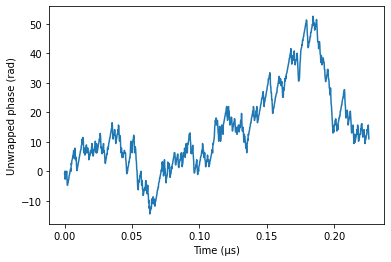

In [113]:
config = {"res_ch": 1, "relax_delay": 1,
          "pulse_gain": 15000,
          "freq_start": 0, "freq_max": 10,
          "vel_start": 2.0, "accel": 0.9,
          "n_segments": 50, "seg_len": 10,
          "reps": 100000}   # DAC repeats this many times, in hardware

prog = ChirpOnlyProgram(soccfg, config)
prog.run_rounds(soc, progress=False)

raw = np.asarray(iq[0])   # shape (2, 1000) -- no reps axis when reps=1
I = raw[0]
Q = raw[1]
trace = I + 1j * Q        # shape (1000,)

config["pulse_freq_center"] = 50
t_axis = np.arange(len(trace)) / fs   # µs, since fs is in MHz (~4423.68)

plt.plot(t_axis, np.abs(trace))
plt.xlabel("Time (µs)")
# plt.xlim(0, 0.1)

plt.ylabel("Amplitude (a.u.)")

plt.show()
amp = np.abs(trace)

phase = np.unwrap(np.angle(trace))

plt.plot(t_axis, phase)
plt.xlabel("Time (µs)")
plt.ylabel("Unwrapped phase (rad)")
# plt.xlim(0, 0.05)

plt.show()

In [114]:
# def get_expected_phase_reset_per_segment(cfg):
#     n_segments = cfg["n_segments"]
#     seg_len    = cfg["seg_len"]
#     f = cfg["freq_start"]
#     v = cfg["vel_start"]
#     a = cfg["accel"]
#     freq_max = cfg["freq_max"]
#     span = cfg["freq_max"] - cfg["freq_start"]

#     gen_fs = soccfg['gens'][cfg["res_ch"]]['fs']
#     seg_dt = seg_len / gen_fs

#     t_all, phase_all = [], []
#     for i in range(n_segments):
#         # phase within THIS segment only, starting from 0
#         t_local = np.linspace(0, seg_dt, 20)
#         phase_local = 2*np.pi * f * t_local % (2 * np.pi)  # resets to 0 each segment
#         t_all.append(i*seg_dt + t_local)
#         phase_all.append(phase_local)

#         v += a
#         f += v
#         if f >= freq_max:
#             f -= span

#     return np.concatenate(t_all), np.concatenate(phase_all)

# t_theory, phase_theory = get_expected_phase_reset_per_segment(config)
# plt.plot(t_theory, phase_theory, 'o-', label="theoretical (from registers)")
# plt.xlabel("Time (µs)")
# plt.ylabel("Phase (rad)")
# plt.legend()
# plt.show()
# # Plot results.
# sig = avgi[0][0] + 1j*avgq[0][0]
# avgamp0 = np.abs(sig)
# plt.figure(1)
# plt.plot(expt_pts, avgi[0][0], label="I value; ADC 0")
# plt.plot(expt_pts, avgq[0][0], label="Q value; ADC 0")
# plt.plot(expt_pts, avgamp0, label="Amplitude; ADC 0")
# # plt.plot(expt_pts, avg_di1, label="I value; ADC 1")
# # plt.plot(expt_pts, avg_dq1, label="Q value; ADC 1")
# # plt.plot(expt_pts, avg_amp1, label="Amplitude; ADC 1")
# plt.ylabel("a.u.")
# plt.xlabel("Pulse gain (DAC units)")
# plt.title("Averages = " + str(config["reps"]))
# plt.legend()
# plt.savefig("images/Gain_sweep.pdf", dpi=350)

### Sweeping via a Python outer loop

In [115]:
# config={"res_ch":6, # --Fixed
#         "ro_ch":0, # --Fixed
#         "relax_delay":1, # --Fixed
#         "res_phase":0, # --Fixed
#         "pulse_style": "const", # --Fixed
#         "length":100, # [Clock ticks]        
#         "readout_length":200, # [Clock ticks]
#         "pulse_gain":0, # [DAC units]
#         "pulse_freq": 100, # [MHz]
#         "adc_trig_offset": 100, # [Clock ticks]
#         "reps":50, 
#        }

# sweep_cfg={"start":0, "step":100, "expts":20}
# gpts=sweep_cfg["start"] + sweep_cfg["step"]*np.arange(sweep_cfg["expts"])

# results=[]
# for g in tqdm(gpts):
#     config["pulse_gain"]=int(g)
#     prog =LoopbackProgram(soccfg, config)
#     results.append(prog.acquire(soc, progress=False))
# results=np.transpose(results)

In [116]:
# sig = results[0][0][0] + 1j*results[0][0][1]
# avgamp0 = np.abs(sig)
# plt.figure(2)
# plt.plot(gpts, results[0][0][0],label="I value; ADC 0")
# plt.plot(gpts, results[0][0][1],label="Q value; ADC 0")
# plt.plot(gpts, avgamp0,label="Amplitude; ADC 0")
# plt.ylabel("a.u.")
# plt.xlabel("Pulse gain (DAC units)")
# plt.title("Averages = " + str(config["reps"]))
# plt.legend()
# plt.savefig("images/Gain_sweep_python.pdf", dpi=350)